In [13]:
import torch
import numpy as np
import matplotlib.pyplot as plt

## Analysis layer 1


In [7]:
layer1 = torch.load('/scratch2/mrenaudin/colorlessgreenRNNs/checkpoints/lstm_adam/layer_1_gate_weights_fc.pt')

In [4]:
layer1.shape

torch.Size([22, 1, 4, 650, 1300])

In [8]:
num_checkpoints = layer1.shape[0]
num_layers = layer1.shape[1]  # Should be 1
num_gates = layer1.shape[2]  # Should be 4
hidden_size = layer1.shape[3]
combined_size = layer1.shape[4]
input_size = combined_size - hidden_size

In [10]:
epochs = np.arange(1, num_checkpoints + 1)


In [17]:
layer_1_sv_whole = []
for checkpoint_idx in range(num_checkpoints):
    # Extract weights for all gates at the current checkpoint
    all_gates_weights = layer1[checkpoint_idx, 0]  # Shape: (4, hidden_size, input_size + hidden_size)
    whole_layer_weight = all_gates_weights.reshape(4 * hidden_size, combined_size).numpy()
    sv_whole = np.linalg.svd(whole_layer_weight, compute_uv=False)
    layer_1_sv_whole.append(sv_whole)


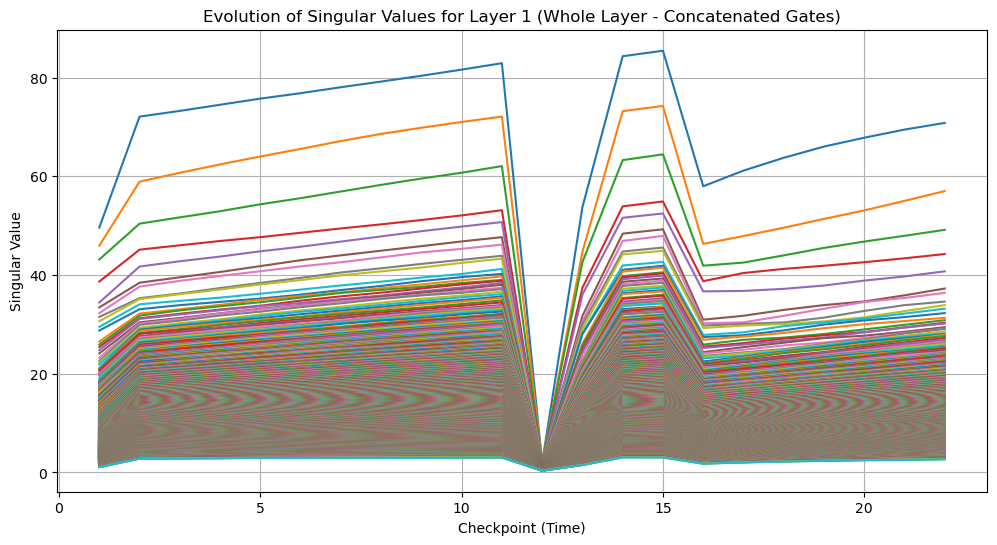

In [18]:
plt.figure(figsize=(12, 6))
for i in range(layer_1_sv_whole[0].shape[0]):
    plt.plot(epochs, [s[i] for s in layer_1_sv_whole], label=f'Singular Value {i+1}')
plt.title('Evolution of Singular Values for Layer 1 (Whole Layer - Concatenated Gates)')
plt.xlabel('Checkpoint (Time)')
plt.ylabel('Singular Value')
#plt.legend(fontsize='small')
plt.grid(True)
plt.show()

In [19]:
layer_1_sv_gates = [[] for _ in range(num_gates)]
gate_names = ["Forget Gate", "Input Gate", "Cell State Gate", "Output Gate"]
epochs = np.arange(1, num_checkpoints + 1)

for checkpoint_idx in range(num_checkpoints):
    for gate_idx in range(num_gates):
        # Extract the weight matrix for the current gate at the current checkpoint
        gate_weight = layer1[checkpoint_idx, 0, gate_idx].numpy()  # Shape: (hidden_size, combined_size)
        singular_values_gate = np.linalg.svd(gate_weight, compute_uv=False)
        layer_1_sv_gates[gate_idx].append(singular_values_gate)

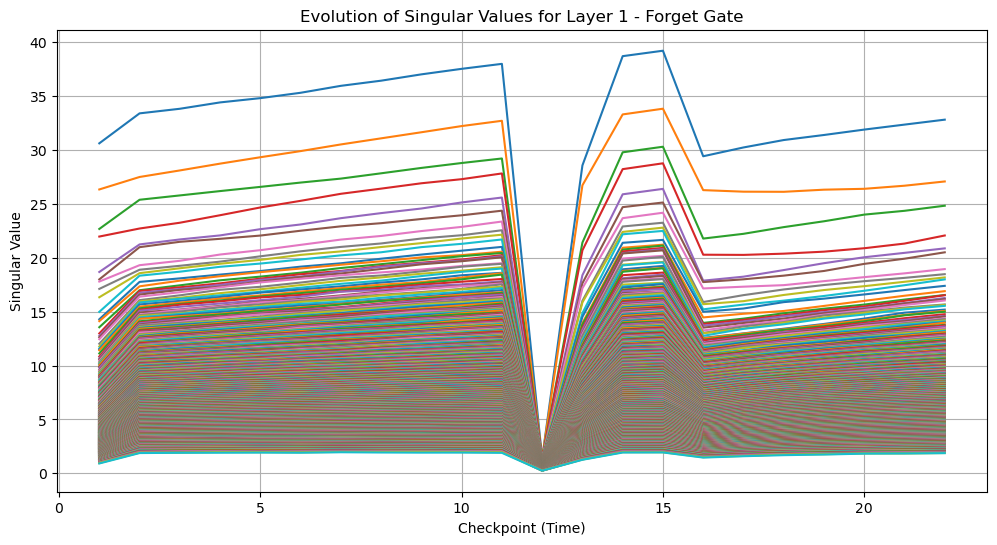

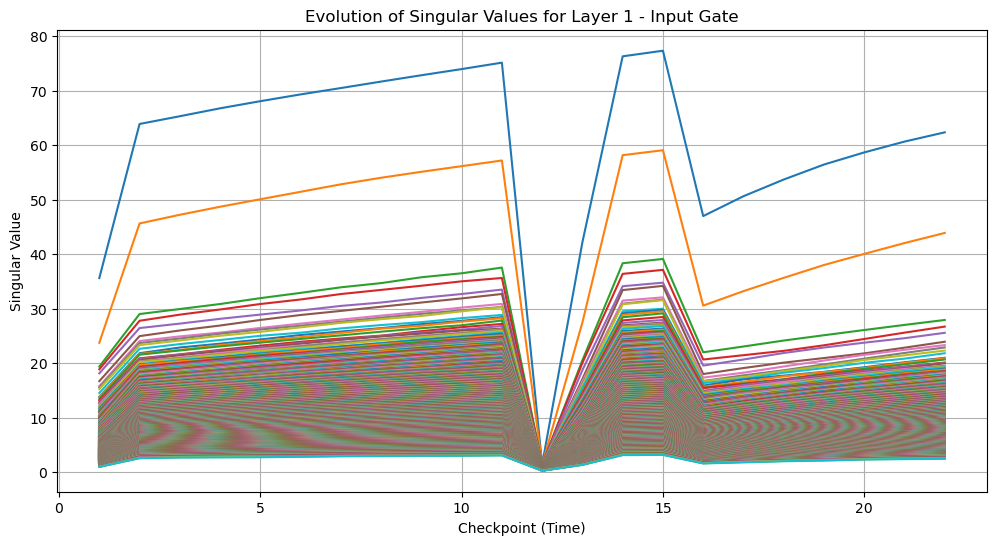

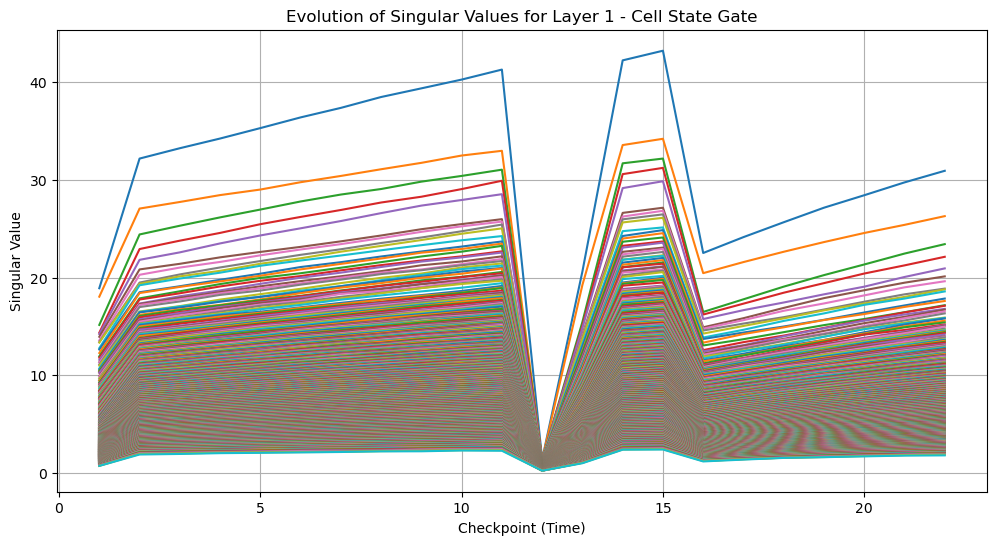

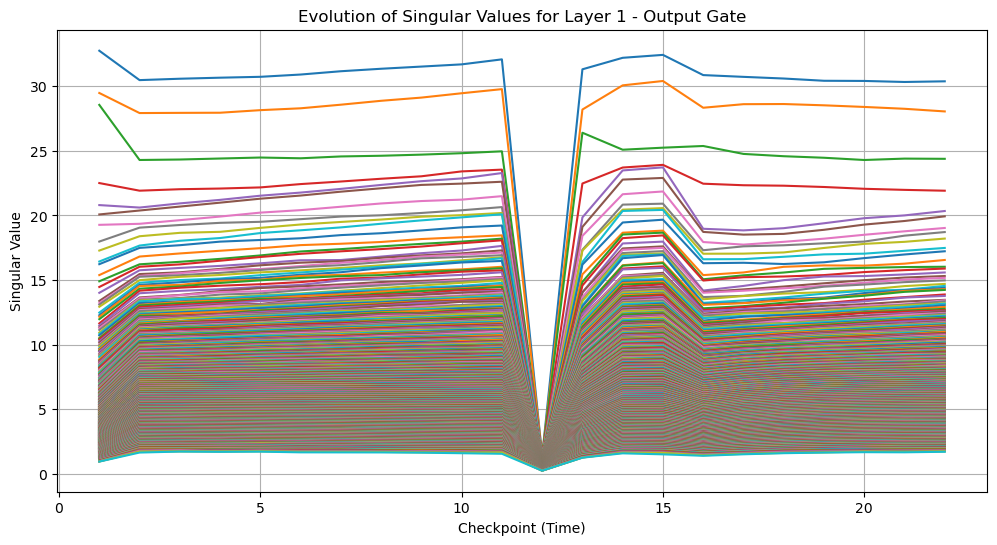

In [21]:
for i, gate_singular_values in enumerate(layer_1_sv_gates):
    plt.figure(figsize=(12, 6))
    for j in range(gate_singular_values[0].shape[0]):
        plt.plot(epochs, [s[j] for s in gate_singular_values], label=f'Singular Value {j+1}')
    plt.title(f'Evolution of Singular Values for Layer 1 - {gate_names[i]}')
    plt.xlabel('Checkpoint (Time)')
    plt.ylabel('Singular Value')
    #plt.legend(fontsize='small')
    plt.grid(True)
    plt.show()

In [29]:
print(layer1.shape)

torch.Size([22, 1, 4, 650, 1300])


In [31]:
layer1[0,0,:,:,:hidden_size].shape

torch.Size([4, 650, 650])

In [37]:
layer_1_eig_rec_gates = [[] for _ in range(num_gates)]
gate_names = ["Forget Gate", "Input Gate", "Cell State Gate", "Output Gate"]
epochs = np.arange(1, num_checkpoints + 1)

for checkpoint_idx in range(num_checkpoints):
    print('ok')
    for gate_idx in range(num_gates):
        # Extract the weight matrix for the current gate at the current checkpoint
        recurrent_gate_weight = layer1[checkpoint_idx, 0, gate_idx, :, :hidden_size].numpy()  # Shape: (hidden_size, combined_size)
        eig_rec_gate = np.linalg.eigvals(recurrent_gate_weight)
        layer_1_eig_rec_gates[gate_idx].append(eig_rec_gate)

ok
ok
ok
ok
ok
ok
ok
ok
ok
ok
ok
ok
ok
ok
ok
ok
ok
ok
ok
ok
ok
ok


In [38]:
layer_1_eig_rec_gates[0][0].shape

(650,)

/tmp/ipykernel_3253037/812602149.py:21: UserWarning: Tight layout not applied. tight_layout cannot make Axes height small enough to accommodate all Axes decorations.
  plt.tight_layout()


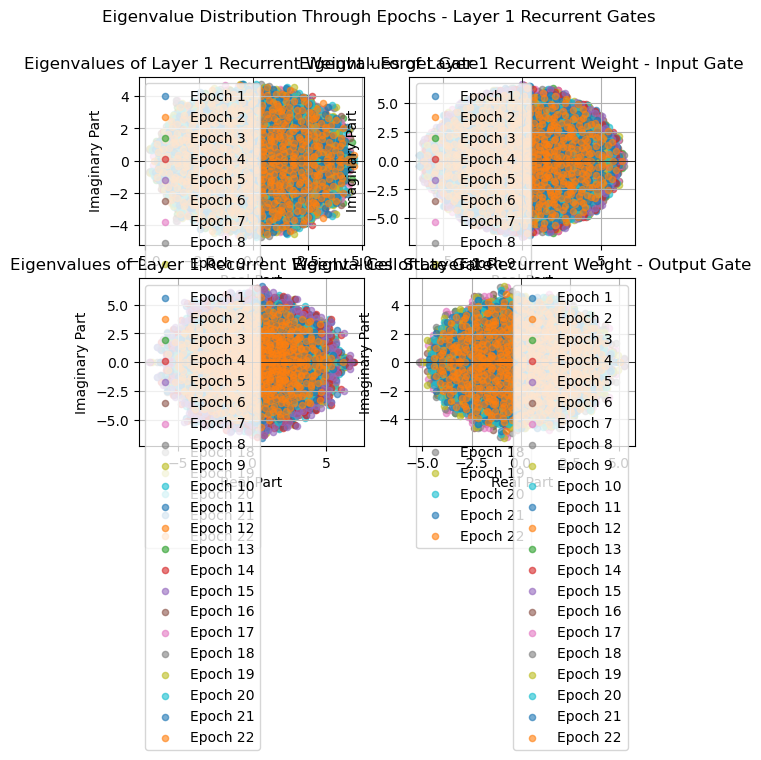

In [ ]:
num_rows = (num_gates + 1) // 2
num_cols = 2
for i in range(num_gates):
    plt.subplot(num_rows, num_cols, i + 1)
    gate_eigenvalues_over_epochs = layer_1_eig_rec_gates[i]

    for epoch_idx, eig_set in enumerate(gate_eigenvalues_over_epochs):
        real_parts = np.real(eig_set)
        imag_parts = np.imag(eig_set)
        epoch_label = f'Epoch {epochs[epoch_idx]}'
        plt.scatter(real_parts, imag_parts, label=epoch_label, alpha=0.6, s=20)

    plt.title(f'Eigenvalues of Layer 1 Recurrent Weight - {gate_names[i]}')
    plt.xlabel('Real Part')
    plt.ylabel('Imaginary Part')
    plt.grid(True)
    plt.axhline(0, color='black', linewidth=0.5)
    plt.axvline(0, color='black', linewidth=0.5)
    #plt.legend()

plt.tight_layout()
plt.suptitle('Eigenvalue Distribution Through Epochs - Layer 1 Recurrent Gates', y=1.02)
plt.show()

In [ ]:
for i, rec_gate_eig in enumerate(layer_1_eig_rec_gates):
    plt.figure(figsize=(12, 6))
    for j in range(gate_singular_values[0].shape[0]):
        plt.plot(epochs, [s[j] for s in gate_singular_values], label=f'Singular Value {j+1}')
    plt.title(f'Evolution of Singular Values for Layer 1 - {gate_names[i]}')
    plt.xlabel('Checkpoint (Time)')
    plt.ylabel('Singular Value')
    #plt.legend(fontsize='small')
    plt.grid(True)
    plt.show()

## Layer 2

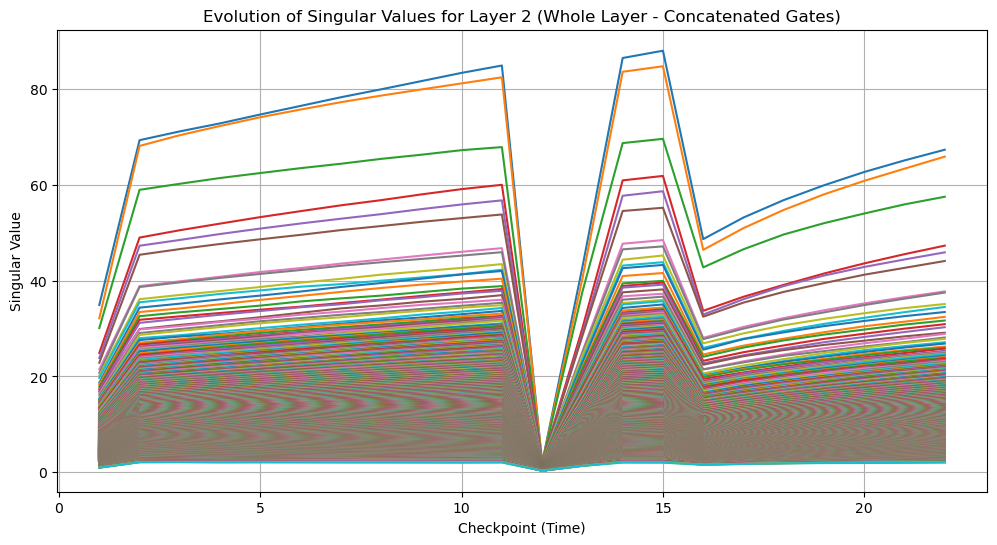

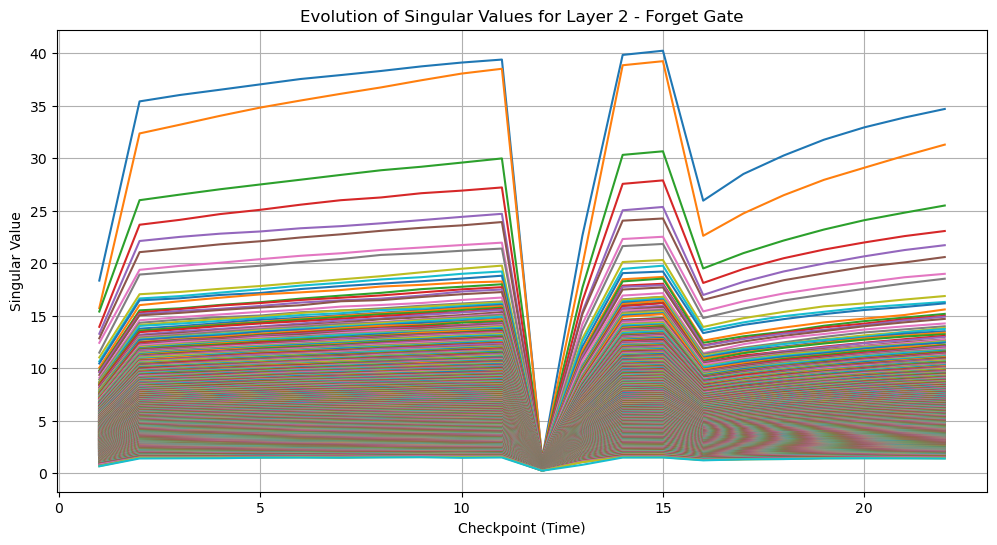

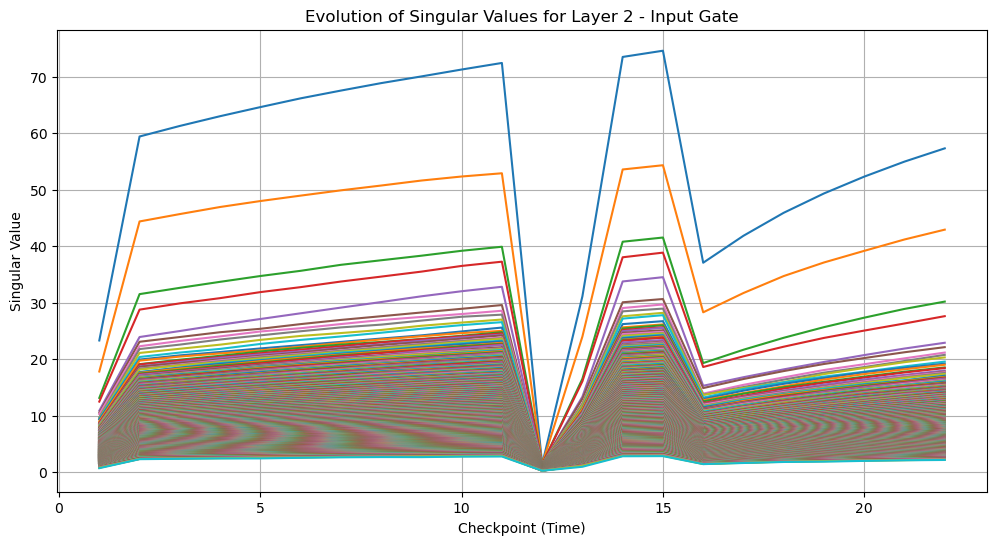

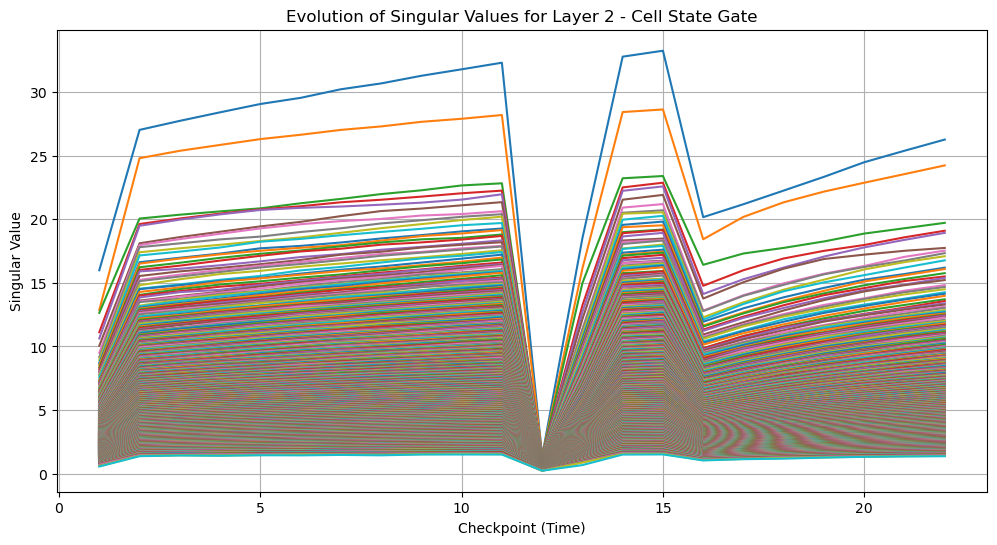

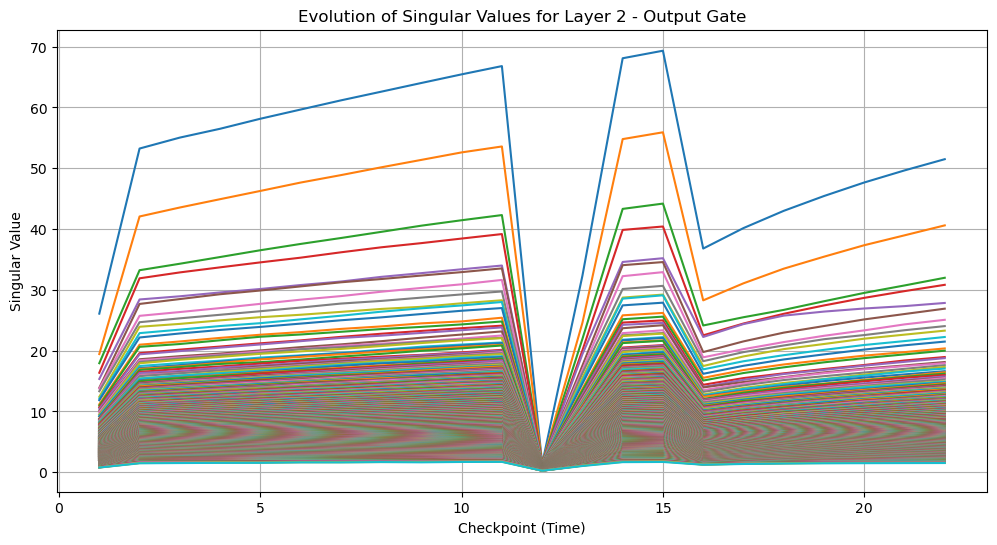

In [23]:
layer2 = torch.load('/scratch2/mrenaudin/colorlessgreenRNNs/checkpoints/lstm_adam/layer_2_gate_weights_fc.pt')
num_checkpoints = layer2.shape[0]
num_layers = layer2.shape[1]  # Should be 1
num_gates = layer2.shape[2]  # Should be 4
hidden_size = layer2.shape[3]
combined_size = layer2.shape[4]
input_size = combined_size - hidden_size

#Whole layer
layer_2_sv_whole = []
for checkpoint_idx in range(num_checkpoints):
    # Extract weights for all gates at the current checkpoint
    all_gates_weights = layer2[checkpoint_idx, 0]  # Shape: (4, hidden_size, input_size + hidden_size)
    whole_layer_weight = all_gates_weights.reshape(4 * hidden_size, combined_size).numpy()
    sv_whole = np.linalg.svd(whole_layer_weight, compute_uv=False)
    layer_2_sv_whole.append(sv_whole)
plt.figure(figsize=(12, 6))
for i in range(layer_2_sv_whole[0].shape[0]):
    plt.plot(epochs, [s[i] for s in layer_2_sv_whole], label=f'Singular Value {i+1}')
plt.title('Evolution of Singular Values for Layer 2 (Whole Layer - Concatenated Gates)')
plt.xlabel('Checkpoint (Time)')
plt.ylabel('Singular Value')
#plt.legend(fontsize='small')
plt.grid(True)
plt.show()

#By gate
layer_2_sv_gates = [[] for _ in range(num_gates)]
gate_names = ["Forget Gate", "Input Gate", "Cell State Gate", "Output Gate"]
epochs = np.arange(1, num_checkpoints + 1)

for checkpoint_idx in range(num_checkpoints):
    for gate_idx in range(num_gates):
        # Extract the weight matrix for the current gate at the current checkpoint
        gate_weight = layer2[checkpoint_idx, 0, gate_idx].numpy()  # Shape: (hidden_size, combined_size)
        singular_values_gate = np.linalg.svd(gate_weight, compute_uv=False)
        layer_2_sv_gates[gate_idx].append(singular_values_gate)

for i, gate_singular_values in enumerate(layer_2_sv_gates):
    plt.figure(figsize=(12, 6))
    for j in range(gate_singular_values[0].shape[0]):
        plt.plot(epochs, [s[j] for s in gate_singular_values], label=f'Singular Value {j+1}')
    plt.title(f'Evolution of Singular Values for Layer 2 - {gate_names[i]}')
    plt.xlabel('Checkpoint (Time)')
    plt.ylabel('Singular Value')
    #plt.legend(fontsize='small')
    plt.grid(True)
    plt.show()